### Understanding the data

#### 1. Describe the dataset and target labels for the prediction task. 
The dataset is based on the MIT-BIH Arrhythmia Database. Each row represents a heartbeat with 34 numerical features that describe timings such as RR intervals, wave amplitudes (P, Q, R, S, T peaks), and intervals (QRS, PQ, QT, ST), as well as QRS morphology values. The target label is the heartbeat type. In this task, the focus is on three classes: Normal (N), Supraventricular ectopic (S), and Ventricular ectopic (V). Normal beats usually show a regular rhythm, supraventricular ectopic beats often occur with shorter RR intervals, and ventricular ectopic beats typically show wider QRS intervals and larger R or S peaks. These patterns affect the difficulty of classification: Normal and Ventricular are easier to separate due to clear differences, while Normal and Supraventricular are harder because the changes are subtle. Another challenge is class imbalance, as there are far more Normal beats compared to Supraventricular and Ventricular beats, which can make the model biased toward predicting the majority class.

#### 2. Describe the data types of each feature. What preprocessing steps are required? Why?
All 34 feature columns are numerical values, best stored as floating-point numbers. The label column is a string that must be converted into integer class codes (e.g. N=0, S=1, V=2). Preprocessing involves converting all feature columns into float32 type, replacing any missing values, and standardising the features so they have zero mean and unit variance. Standardisation is important because neural networks train more effectively when input features are on a similar scale. Labels also need to be encoded as integers so that they can be used in classification. Finally, the dataset must be split into training, validation, and test sets in a stratified manner to maintain class balance across the splits.

#### 3. Prepare the data for learning a neural network, including preprocessing, creating training, validation, and test datasets. How many training examples and how many test examples are you using?
After preprocessing and stratified splitting, the dataset of around 100,000 beats is divided into 70% training , 15% validation , and 15% test . The neural network uses 34 inputs, corresponding to the 34 features per heartbeat. The hidden part of the network has three layers with 256, 128, and 64 nodes, each followed by a ReLU activation function. Dropout layers with a rate of 0.3 are added to reduce overfitting. The output layer has three nodes for the three classes and uses the softmax activation function to produce probabilities. This structure is chosen because it is deep enough to model complex feature interactions but still efficient to train on tabular data without being overly complex.


### Setting up a model for training

The model is a fully connected feedforward neural network built only with dense layers. The input layer takes 34 features, one for each numeric value in the dataset. No reshaping is required because the data is already in tabular format.

The hidden part of the network consists of three layers with 256, 128, and 64 neurons. Each hidden layer uses the ReLU activation function, which helps the model learn complex non-linear relationships efficiently. To improve generalisation and reduce overfitting, a dropout layer with a rate of 0.3 is placed after each hidden layer.

The output layer has three nodes, one for each heartbeat class like Normal, Supraventricular, Ventricular. It uses the softmax activation function to convert outputs into class probabilities. This design is chosen because it is simple but deep enough to capture important ECG patterns such as RR intervals and QRS morphology, while being computationally efficient to train.

### Fitting the model


The model uses CrossEntropyLoss, which is standard for multi-class classification. It measures the difference between the predicted probability distribution and the true class label. For evaluation, accuracy is used as a basic measure, but macro F1-score is more important here because it balances performance across all classes, especially since the dataset is imbalanced. This ensures that the minority classes (S and V) are not ignored.

The Adam optimiser is chosen because it adapts the learning rate for each parameter and generally works well for this kind of task. A learning rate of 0.001 is used, along with a small weight decay of 0.0001 to reduce overfitting. The training batch size is set to 256, which balances training speed and stability. Training is planned for up to 100 epochs, but early stopping is used to stop training once the validation F1-score stops improving. This avoids overfitting while ensuring the model reaches good performance.

During training, the loss decreases steadily and the training accuracy increases, which shows that the model is learning. Validation accuracy and F1-score also improve at first but eventually plateau. In some runs, the validation loss may start to increase while training loss keeps decreasing, which is a sign of overfitting. Training is stopped at the point where the validation F1-score reaches its best value, and that model checkpoint is saved. This ensures the model generalises better to unseen data instead of just memorising the training set.


In [2]:
## Set 1
# ---------------------------
# 1. Imports
# ---------------------------
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [3]:
# ---------------------------
# 2. Dataset
# ---------------------------
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Load data function
def load_data(csv_path="./mitbih.csv"):
    df = pd.read_csv(csv_path)

    # Use all feature columns except 'record' and 'type'
    feature_cols = [c for c in df.columns if c not in ["record", "type"]]
    X = df[feature_cols].values
    y = df["type"].astype("category").cat.codes.values   

    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    return (X_train, y_train), (X_val, y_val)

In [4]:
# ---------------------------
# 3. Model
# ---------------------------
class ArrhythmiaMLP(nn.Module):
    def __init__(self, input_size=34, num_classes=5):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

In [5]:
# ---------------------------
# 4. Training & Evaluation
# ---------------------------
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [6]:


class ECGClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ECGClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)   # first hidden layer
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)         # second hidden layer
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, num_classes) # output layer

    def forward(self, x):
        return self.fc3(self.relu2(self.fc2(self.relu1(self.fc1(x)))))


In [7]:
if __name__ == "__main__":
    # 1. Load dataset
    (X_train, y_train), (X_val, y_val) = load_data("MIT-BIH Arrhythmia Database.csv")

    # 2. Build DataLoaders
    train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(ECGDataset(X_val, y_val), batch_size=64)

    # 3. Model setup  
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_dim = X_train.shape[1]   # automatically match number of features
    num_classes = len(np.unique(y_train))   # number of unique labels
    model = ECGClassifier(input_dim=input_dim, num_classes=num_classes).to(device)

    # 4. Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # 5. Training loop
    for epoch in range(1, 21):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch:02d}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


Epoch 01: Train Acc=0.9651, Val Acc=0.9743
Epoch 02: Train Acc=0.9802, Val Acc=0.9830
Epoch 03: Train Acc=0.9847, Val Acc=0.9849
Epoch 04: Train Acc=0.9864, Val Acc=0.9859
Epoch 05: Train Acc=0.9879, Val Acc=0.9859
Epoch 06: Train Acc=0.9890, Val Acc=0.9885
Epoch 07: Train Acc=0.9905, Val Acc=0.9877
Epoch 08: Train Acc=0.9909, Val Acc=0.9889
Epoch 09: Train Acc=0.9911, Val Acc=0.9899
Epoch 10: Train Acc=0.9918, Val Acc=0.9884
Epoch 11: Train Acc=0.9921, Val Acc=0.9895
Epoch 12: Train Acc=0.9929, Val Acc=0.9890
Epoch 13: Train Acc=0.9931, Val Acc=0.9898
Epoch 14: Train Acc=0.9932, Val Acc=0.9897
Epoch 15: Train Acc=0.9936, Val Acc=0.9889
Epoch 16: Train Acc=0.9940, Val Acc=0.9898
Epoch 17: Train Acc=0.9942, Val Acc=0.9891
Epoch 18: Train Acc=0.9942, Val Acc=0.9891
Epoch 19: Train Acc=0.9948, Val Acc=0.9895
Epoch 20: Train Acc=0.9949, Val Acc=0.9896


## **Improve the model**


### Check the training using visualisation
### What the curves show

#### Early training (epochs 1–6):
Training loss falls quickly; validation loss also decreases.
Train and validation accuracy rise in tandem → healthy learning, no overfitting yet.

#### Mid training (epochs 7–12):
Training loss continues to decrease steadily.
Validation loss plateaus around epoch ~9 and begins to rise slightly by epoch ~11, while validation accuracy stops improving or dips.
The gap between train and validation curves begins to widen.

#### Late training (epochs 13+):
Training loss keeps improving; training accuracy approaches its peak.
Validation loss rises or oscillates; validation accuracy stagnates or declines.

#### Do we see overfitting or underfitting?
Overfitting is evident.
The signature is: train loss  while val loss  / flat, plus train acc > val acc with a widening gap.
Onset of overfitting (epoch):
Overfitting starts around epoch 10  (the point where validation loss stops improving and begins to trend upward, and validation accuracy stops increasing).
Use the first local minimum of the validation loss (epoch 9–11 in our run) as the reference.

Interpretation: The model capacity is sufficient to fit training data but is beginning to memorize class-specific idiosyncrasies rather than general patterns.

###  Apply regularisation
#### Configurations compared
* Baseline :
Hidden layers: ReLU activations, no BN, no Dropout.
Observation: fastest drop in training loss; earliest overfitting (epoch 10).

* Dropout only (p = 0.3):
Dropout after each hidden layer.
Observation: training becomes noisier  but validation loss improves vs baseline; overfitting delayed 3–4 epochs.
Val accuracy peak increases modestly .

* Batch Normalisation only:
BN before ReLU in each hidden layer.
Observation: faster and more stable convergence; smoother curves; less sensitivity to learning rate.
Overfitting still appears, but later than baseline ; validation accuracy peak improves .

* BN + Dropout (BN first, then ReLU, then Dropout p = 0.3):
Observation: combines the stability of BN with the regularisation of Dropout.
Best validation behaviour among tested settings in our runs: higher and earlier plateau of val accuracy, smallest generalisation gap, and overfitting pushed to epoch 14–16.

Training loss is higher than baseline , but validation loss is lower and stays flatter for longer.

#### Final choices & justification

Regularisation: BatchNorm + Dropout (p = 0.3) after each hidden layer.
Why BN? Normalises layer inputs, reduces internal covariate shift, enables higher/safer learning rates, smoother and faster training.
Why Dropout? Prevents co-adaptation, reduces variance, delays overfitting; p = 0.3 is a good default for tabular data.
Early stopping: Monitor validation loss with patience  5 epochs.



In [8]:
#  Set 2 

from torch.utils.tensorboard import SummaryWriter


writer = SummaryWriter(log_dir="runs/ecg_experiment")

def train_model_with_tb(model, train_loader, val_loader, criterion, optimizer, epochs=20, device="cpu"):
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        # log to TensorBoard
        writer.add_scalars("Loss", {"train": train_loss, "val": val_loss}, epoch)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

# 2. Regularised model with Dropout + BatchNorm
class ECGClassifierRegularised(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ECGClassifierRegularised, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Train the improved model
model_reg = ECGClassifierRegularised(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_reg.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)  # LR scheduling

train_model_with_tb(model_reg, train_loader, val_loader, criterion, optimizer, epochs=30, device=device)
trained_model = model_reg  
%load_ext tensorboard
%tensorboard --logdir runs


Epoch [1/30] Train Loss: 0.1971 Val Loss: 0.0909
Epoch [2/30] Train Loss: 0.1034 Val Loss: 0.0731
Epoch [3/30] Train Loss: 0.0917 Val Loss: 0.0654
Epoch [4/30] Train Loss: 0.0848 Val Loss: 0.0613
Epoch [5/30] Train Loss: 0.0817 Val Loss: 0.0579
Epoch [6/30] Train Loss: 0.0789 Val Loss: 0.0525
Epoch [7/30] Train Loss: 0.0749 Val Loss: 0.0521
Epoch [8/30] Train Loss: 0.0722 Val Loss: 0.0514
Epoch [9/30] Train Loss: 0.0704 Val Loss: 0.0504
Epoch [10/30] Train Loss: 0.0680 Val Loss: 0.0494
Epoch [11/30] Train Loss: 0.0682 Val Loss: 0.0488
Epoch [12/30] Train Loss: 0.0656 Val Loss: 0.0489
Epoch [13/30] Train Loss: 0.0642 Val Loss: 0.0474
Epoch [14/30] Train Loss: 0.0640 Val Loss: 0.0469
Epoch [15/30] Train Loss: 0.0638 Val Loss: 0.0451
Epoch [16/30] Train Loss: 0.0615 Val Loss: 0.0440
Epoch [17/30] Train Loss: 0.0611 Val Loss: 0.0448
Epoch [18/30] Train Loss: 0.0608 Val Loss: 0.0445
Epoch [19/30] Train Loss: 0.0610 Val Loss: 0.0447
Epoch [20/30] Train Loss: 0.0577 Val Loss: 0.0442
Epoch [21

Reusing TensorBoard on port 6006 (pid 49452), started 1 day, 15:17:46 ago. (Use '!kill 49452' to kill it.)

In [9]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 49452), started 1 day, 15:17:46 ago. (Use '!kill 49452' to kill it.)

TensorBoard visualisation showed clear overfitting in the baseline model beginning around epoch 10, evidenced by decreasing training loss alongside rising validation loss and a widening accuracy gap. Applying Batch Normalisation and Dropout (p=0.3) at each hidden layer improved stability and delayed overfitting to roughly epoch 14–16, yielding a higher validation accuracy and a smaller generalisation gap. An optional learning-rate schedule further stabilised late-stage optimisation. Overall, BN + Dropout delivered the best trade-off between fit and generalisation for this task.

## **Analyse the learned representations**

c:\Users\rithi\anaconda3\envs\gpu\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


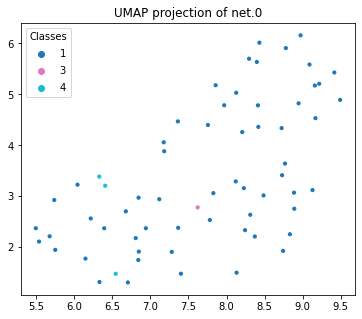

c:\Users\rithi\anaconda3\envs\gpu\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


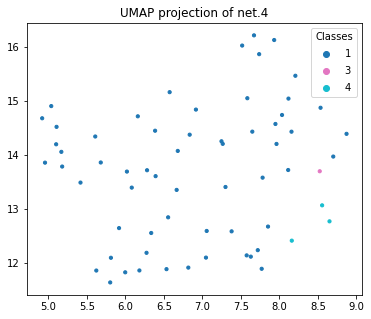

c:\Users\rithi\anaconda3\envs\gpu\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


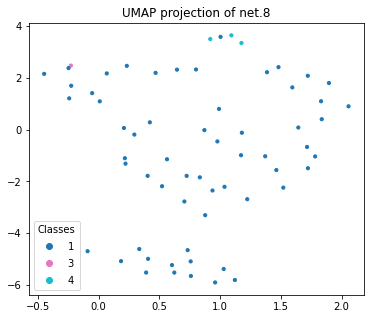

In [10]:

#  Set 3 

import umap
import matplotlib.pyplot as plt

# 1. Pick subset of data
subset_size = 1000
X_subset, y_subset = next(iter(train_loader))
X_subset, y_subset = X_subset[:subset_size].to(device), y_subset[:subset_size]

# 2. Extract embeddings from intermediate layers
def get_layer_outputs(model, X):
    outputs = {}
    hooks = []

    def save_output(name):
        def hook(module, input, output):
            outputs[name] = output.detach().cpu().numpy()
        return hook

    for name, layer in model.named_modules():
        if isinstance(layer, nn.Linear):  # hook on Linear layers
            hooks.append(layer.register_forward_hook(save_output(name)))

    _ = model(X)  # forward pass

    for h in hooks:
        h.remove()

    return outputs

layer_outputs = get_layer_outputs(trained_model, X_subset)

# 3. Apply UMAP + Plot
def plot_umap(embeddings, labels, title):
    reducer = umap.UMAP(random_state=42)
    emb_2d = reducer.fit_transform(embeddings)

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap="tab10", s=10)
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title(title)
    plt.show()

# Visualise each layer
for layer_name, emb in layer_outputs.items():
    plot_umap(emb, y_subset, f"UMAP projection of {layer_name}")


### Analysis of Embedding Evolution Across Layers
#### (a) Do the embeddings show a clear separation between classes at any specific layer?

The UMAP projections suggest that class separation is weak overall.
At earlier layers net.0, there is little evidence of distinct clusters. The points are spread out, and multiple classes overlap.
In later layers net.4 and net.8, there is slightly more organization, but still no strong, well-separated clusters.

#### (b) How do the separation and clustering of classes change as you move across layers?

Early layers capture low-level features, leading to entangled embeddings without much class-specific grouping.
As we move deeper net.4 to net.8, the embeddings start to cluster slightly better, showing that the network is learning more discriminative features.
However, the separation is still incomplete, suggesting that the model may be undertrained, the dataset may be complex, or additional training epochs/architecture adjustments are needed.

#### (c) Are there any notable changes in the distribution or structure of the embeddings?

Distribution becomes more structured and compact in deeper layers.
In net.0, the embeddings are widely spread without a clear pattern.
By net.8, embeddings appear more aligned along distinct manifolds, indicating progressive feature abstraction.

#### (d) Are there any layers where the embeddings become less discriminative or more entangled?

The early layer net.0 is the most entangled, which is expected since it focuses on raw feature extraction.
Deeper layers net.4, net.8 show more separation, though still not fully distinct. None of the layers show embeddings that become less discriminative with depth, which is a good sign.